# YOLOv8-Seg | Training from Scratch
Multi-label clothing detection + instance segmentation - 5 classes  
Backbone: CSPDarknet | Neck: PAN-FPN | Heads: Detection + Segmentation  
Init: Random (no pretrained weights) | Loss: CIoU + BCE + Segmentation

## 1. Install & Imports

In [ ]:

!pip install ultralytics --quiet

import os, json, shutil, random, math, glob
import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from ultralytics import YOLO
import yaml

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU count: {torch.cuda.device_count()}')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.9 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cu128
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Configuration

In [ ]:

BASE_DIR      = '/kaggle/input/datasets/fashion/processed'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train', 'images')
TRAIN_ANN_DIR = os.path.join(BASE_DIR, 'train', 'annos')
VAL_IMG_DIR   = os.path.join(BASE_DIR, 'validation', 'images')
VAL_ANN_DIR   = os.path.join(BASE_DIR, 'validation', 'annos')

YOLO_DIR = '/kaggle/working/yolo_dataset'


CAT_REMAP = {1: 0, 2: 1, 7: 2, 8: 3, 9: 4}
CLASS_NAMES = ['short_sleeve_top', 'long_sleeve_top', 'shorts', 'trousers', 'skirt']
NUM_CLASSES = 5

EPOCHS      = 10
IMGSZ       = 640        
BATCH_SIZE  = 16        
LR0         = 1e-2      
LRF         = 1e-3       
SEED        = 42
WORKERS     = 4      

CKPT_DIR = '/kaggle/working/yolo_scratch'
os.makedirs(CKPT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Base dir exists: {os.path.isdir(BASE_DIR)}')
print(f'Train images: {len(os.listdir(TRAIN_IMG_DIR)):,}')
print(f'Val images:   {len(os.listdir(VAL_IMG_DIR)):,}')

Base dir exists: True
Train images: 144,174
Val images:   23,741


## 3. Data Preprocessing - DeepFashion2 - YOLO Format

YOLO expects:
- `images/{split}/image.jpg`
- `labels/{split}/image.txt` with lines: `class x_center y_center w h x1 y1 x2 y2 ... xn yn` (normalised 0-1)

Val is split 90/10 into val/test **before** any training decisions

In [ ]:
def polygon_to_yolo_seg(polygon_pts, img_w, img_h):
    """Convert absolute polygon [[x,y],...] to normalised YOLO seg coords."""
    coords = []
    for x, y in polygon_pts:
        coords.append(np.clip(x / img_w, 0, 1))
        coords.append(np.clip(y / img_h, 0, 1))
    return coords


def parse_annotation(ann_path, img_w, img_h):
    """
    Parse one DeepFashion2 JSON annotation.
    Returns list of (class_id, bbox_norm, seg_coords_norm) for top-5 categories.
    bbox_norm = [x_c, y_c, w, h] in [0,1]
    seg_coords_norm = flat [x1,y1,x2,y2,...] in [0,1]
    """
    with open(ann_path) as f:
        data = json.load(f)

    records = []
    for key, item in data.items():
        if not key.startswith('item'):
            continue
        cat_id = item.get('category_id', -1)
        if cat_id not in CAT_REMAP:
            continue
        cls = CAT_REMAP[cat_id]

        # Bounding box
        x1, y1, x2, y2 = item['bounding_box']
        x1, x2 = max(0, x1), min(img_w, x2)
        y1, y2 = max(0, y1), min(img_h, y2)
        if x2 <= x1 or y2 <= y1:
            continue
        x_c = (x1 + x2) / 2 / img_w
        y_c = (y1 + y2) / 2 / img_h
        w   = (x2 - x1) / img_w
        h   = (y2 - y1) / img_h

        
        seg_polys = item.get('segmentation', [])
        if not seg_polys:
            continue
        best_poly = max(seg_polys, key=lambda p: len(p))
        pts = [(best_poly[i], best_poly[i+1]) for i in range(0, len(best_poly)-1, 2)]
        if len(pts) < 3:
            continue
        seg_norm = polygon_to_yolo_seg(pts, img_w, img_h)

        records.append((cls, [x_c, y_c, w, h], seg_norm))

    return records


def write_yolo_label(label_path, records):
    """Write YOLO segmentation label file."""
    with open(label_path, 'w') as f:
        for cls, bbox, seg in records:
            seg_str = ' '.join(f'{v:.6f}' for v in seg)
            f.write(f'{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f} {seg_str}\n')


def build_yolo_split(img_dir, ann_dir, out_img_dir, out_lbl_dir, desc=''):
    """
    Convert a DeepFashion2 split to YOLO format.
    Skips images with no top-5 category annotations.
    Returns list of valid image filenames and per-class counts for imbalance analysis.
    """
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    ann_files = sorted(glob.glob(os.path.join(ann_dir, '*.json')))
    valid_files = []
    class_counts = defaultdict(int)
    skipped = 0

    for ann_path in tqdm(ann_files, desc=desc):
        stem = Path(ann_path).stem           
        img_path = os.path.join(img_dir, stem + '.jpg')
        if not os.path.exists(img_path):
            skipped += 1
            continue

        img = Image.open(img_path)
        img_w, img_h = img.size

        records = parse_annotation(ann_path, img_w, img_h)
        if not records:
            skipped += 1
            continue

        
        out_img = os.path.join(out_img_dir, stem + '.jpg')
        if not os.path.exists(out_img):
            os.symlink(img_path, out_img)

        out_lbl = os.path.join(out_lbl_dir, stem + '.txt')
        write_yolo_label(out_lbl, records)

        for cls, _, _ in records:
            class_counts[cls] += 1
        valid_files.append(stem)

    print(f'{desc}: {len(valid_files):,} images kept, {skipped} skipped')
    return valid_files, class_counts


print('Starting DeepFashion2 → YOLO conversion...')
print('This parses every JSON annotation — takes ~5 min for 144K train images.')

Starting DeepFashion2 → YOLO conversion...
This parses every JSON annotation — takes ~5 min for 144K train images.


In [ ]:

train_valid, train_counts = build_yolo_split(
    TRAIN_IMG_DIR, TRAIN_ANN_DIR,
    f'{YOLO_DIR}/images/train',
    f'{YOLO_DIR}/labels/train',
    desc='Train'
)


all_val_valid, val_counts = build_yolo_split(
    VAL_IMG_DIR, VAL_ANN_DIR,
    f'{YOLO_DIR}/images/_val_all',
    f'{YOLO_DIR}/labels/_val_all',
    desc='Val+Test'
)

random.shuffle(all_val_valid)
n_test = int(0.10 * len(all_val_valid))
test_stems = set(all_val_valid[:n_test])
val_stems  = set(all_val_valid[n_test:])

for split_name, stems in [('val', val_stems), ('test', test_stems)]:
    os.makedirs(f'{YOLO_DIR}/images/{split_name}', exist_ok=True)
    os.makedirs(f'{YOLO_DIR}/labels/{split_name}', exist_ok=True)
    for stem in stems:
        src_img = f'{YOLO_DIR}/images/_val_all/{stem}.jpg'
        src_lbl = f'{YOLO_DIR}/labels/_val_all/{stem}.txt'
        dst_img = f'{YOLO_DIR}/images/{split_name}/{stem}.jpg'
        dst_lbl = f'{YOLO_DIR}/labels/{split_name}/{stem}.txt'
        if not os.path.exists(dst_img): os.symlink(os.path.abspath(src_img), dst_img)
        if not os.path.exists(dst_lbl): shutil.copy(src_lbl, dst_lbl)

print(f'\nFinal splits:')
print(f'  Train : {len(train_valid):,}')
print(f'  Val   : {len(val_stems):,}')
print(f'  Test  : {len(test_stems):,}')

print(f'\nClass distribution (train instance counts):')
total = sum(train_counts.values())
for cls_id, name in enumerate(CLASS_NAMES):
    cnt = train_counts[cls_id]
    print(f'  {name:<22}: {cnt:>6}  ({cnt/total*100:.1f}%)')

Train: 100%|██████████| 144174/144174 [38:36<00:00, 62.24it/s] 


Train: 144,174 images kept, 0 skipped


Val+Test: 100%|██████████| 23741/23741 [07:23<00:00, 53.48it/s]


Val+Test: 23,741 images kept, 0 skipped

Final splits:
  Train : 144,174
  Val   : 21,367
  Test  : 2,374

Class distribution (train instance counts):
  short_sleeve_top      :  71644  (31.1%)
  long_sleeve_top       :  36064  (15.6%)
  shorts                :  36616  (15.9%)
  trousers              :  55387  (24.0%)
  skirt                 :  30835  (13.4%)


## 4. Class Imbalance - Compute pos_weight for Loss

Ultralytics YOLOv8 accepts `cls_pw` (classification positive weight) per class.  
We compute `neg/pos` ratio per class, then pass as a list to the trainer config.

In [ ]:

counts = np.array([train_counts[i] for i in range(NUM_CLASSES)], dtype=np.float32)
total_instances = counts.sum()
# pos_weight = total / (num_classes * count_i)  — standard inverse freq weighting
pos_weights = total_instances / (NUM_CLASSES * counts)
# Clip to avoid extreme values for very rare classes
pos_weights = np.clip(pos_weights, 0.5, 10.0)

print('Per-class pos_weights for classification loss:')
for name, w in zip(CLASS_NAMES, pos_weights):
    print(f'  {name:<22}: {w:.3f}')

mean_cls_pw = float(pos_weights.mean())
print(f'\nMean cls_pw to pass to YOLO trainer: {mean_cls_pw:.3f}')

Per-class pos_weights for classification loss:
  short_sleeve_top      : 0.644
  long_sleeve_top       : 1.279
  shorts                : 1.259
  trousers              : 0.832
  skirt                 : 1.495

Mean cls_pw to pass to YOLO trainer: 1.102


## 5. Dataset YAML

In [9]:
dataset_yaml = {
    'path'  : YOLO_DIR,
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : NUM_CLASSES,
    'names' : CLASS_NAMES
}

yaml_path = f'{YOLO_DIR}/dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('dataset.yaml written:')
print(open(yaml_path).read())

dataset.yaml written:
names:
- short_sleeve_top
- long_sleeve_top
- shorts
- trousers
- skirt
nc: 5
path: /kaggle/working/yolo_dataset
test: images/test
train: images/train
val: images/val



## 6. Model - YOLOv8-seg from Scratch

**Architecture:**
- Backbone: CSPDarknet (C2f blocks) - hierarchical CNN feature extractor
- Neck: PAN-FPN - multi-scale feature aggregation
- Detection head: predicts boxes + class probs at 3 scales
- Segmentation head: 32 mask prototypes + per-instance coefficients

**`pretrained=False`** means all weights are randomly initialised.  
Ultralytics uses Kaiming Normal for conv layers by default (same as PyTorch nn.Conv2d default init), which is correct for ReLU/SiLU activations.

In [ ]:
model = YOLO('yolov8m-seg.yaml') 

# Verify no pretrained weights loaded
total_params = sum(p.numel() for p in model.model.parameters())
print(f'Total parameters: {total_params/1e6:.1f}M')
print('Model loaded from YAML — random initialisation (no pretrained weights)')

# Verify multi-GPU will be used
n_gpu = torch.cuda.device_count()
device_str = ','.join(str(i) for i in range(n_gpu)) if n_gpu > 1 else '0'
print(f'Training device(s): {device_str}  ({n_gpu} GPU(s))')

Total parameters: 27.3M
Model loaded from YAML — random initialisation (no pretrained weights)
Training device(s): 0,1  (2 GPU(s))


## 7. Training

In [ ]:
# Ultralytics handles:
#   - Multi-GPU (DataParallel) automatically via device='0,1'
#   - persistent_workers internally (no worker respawn hang)
#   - Mixed precision (AMP) automatically
#   - Best checkpoint saved to project/name/weights/best.pt
#   - Last checkpoint saved to project/name/weights/last.pt
#   - Resume via resume=True on restart

results = model.train(
    data      = yaml_path,
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH_SIZE,
    device    = device_str,
    workers   = WORKERS,
    project   = CKPT_DIR,
    name      = 'scratch',
    exist_ok  = True,

    # Optimiser — SGD with cosine LR decay is standard for YOLO from scratch
    optimizer = 'SGD',
    lr0       = LR0,
    lrf       = LRF / LR0,   # final LR = lr0 * lrf
    momentum  = 0.937,
    weight_decay = 5e-4,
    warmup_epochs = 3.0,      # more warmup needed from scratch vs finetune
    warmup_momentum = 0.8,

    # Loss weights — class imbalance via cls_pw
    cls       = 0.5,          # classification loss weight
    box       = 7.5,          # box regression loss weight
    dfl       = 1.5,          # distribution focal loss weight
    label_smoothing = 0.1,   # positive weight for BCE classification loss

    # Augmentation — mosaic + standard augmentations
    # These are YOLO defaults; good for clothing detection
    mosaic    = 1.0,
    mixup     = 0.1,
    degrees   = 0.0,          
    translate = 0.1,
    scale     = 0.5,
    fliplr    = 0.5,
    flipud    = 0.0,          
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,

    # Eval
    val       = True,
    save      = True,
    save_period = 1,          # checkpoint every epoch
    plots     = True,
    verbose   = False,
    seed      = SEED,
)

best_ckpt = f'{CKPT_DIR}/scratch/weights/best.pt'
print(f'\nBest checkpoint: {best_ckpt}')
print(f'Best mAP50-95: {results.results_dict.get("metrics/mAP50-95(B)", "N/A")}')

## 8. Final Evaluation on Test Set

Load best checkpoint, run once on held-out test set.  

In [13]:
best_ckpt = '/kaggle/input/models/arnavoruganty/best-ouput/pytorch/default/1/best.pt'
best_model = YOLO(best_ckpt)

# COCO-style evaluation on test set
# Returns mAP@0.5, mAP@0.5:0.95, per-class AP for both boxes and masks
test_results = best_model.val(
    data    = yaml_path,
    split   = 'test',
    imgsz   = IMGSZ,
    batch   = BATCH_SIZE,
    device  = device_str,
    verbose = True,
    plots   = True,
    save_json = True,   # saves COCO-format predictions for further analysis
    project = CKPT_DIR,
    name    = 'test_eval',
    exist_ok = True,
)

print('\n' + '='*70)
print('TEST SET RESULTS — YOLOv8-seg (Scratch)')
print('='*70)
rd = test_results.results_dict
print(f"{'Metric':<35} {'Value':>10}")
print('-'*46)
for k, v in rd.items():
    if isinstance(v, float):
        print(f'{k:<35} {v:>10.4f}')

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,225,279 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 89.8±39.8 MB/s, size: 56.9 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/test... 2374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2374/2374 1.1Kit/s 2.2s0.1ss
val: New cache created: /kaggle/working/yolo_dataset/labels/test.cache
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 181ms
Prepared 1 package in 44ms
Installed 1 package in 4ms
 + faster-coco-eval==1.7.2

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instances      Box(P          R 

## 9. Per-Class Detection Metrics (mAP, F1, AUC, ROC)

In [ ]:


def print_per_class_detection(results_obj, split_name='Test'):
    """Print per-class detection metrics from Ultralytics results."""
    maps  = results_obj.box.maps    # per-class mAP50-95
    maps50 = results_obj.box.ap50  # per-class mAP50
    prec  = results_obj.box.p      # per-class precision
    rec   = results_obj.box.r      # per-class recall

    print(f'\n{split_name} — Per-Class Detection (Bounding Box)')
    print(f'{"Class":<22} {"Precision":>10} {"Recall":>10} {"mAP50":>10} {"mAP50-95":>10} {"F1":>10}')
    print('-'*74)
    for i, name in enumerate(CLASS_NAMES):
        p  = prec[i]  if i < len(prec)  else 0
        r  = rec[i]   if i < len(rec)   else 0
        m50  = maps50[i] if i < len(maps50) else 0
        m    = maps[i]   if i < len(maps)   else 0
        f1 = 2*p*r/(p+r+1e-8)
        print(f'{name:<22} {p:>10.4f} {r:>10.4f} {m50:>10.4f} {m:>10.4f} {f1:>10.4f}')
    print('-'*74)
    macro_f1 = np.mean([2*prec[i]*rec[i]/(prec[i]+rec[i]+1e-8) for i in range(min(len(prec), NUM_CLASSES))])
    print(f'{"Macro-avg":<22} {np.mean(prec):>10.4f} {np.mean(rec):>10.4f} '
          f'{np.mean(maps50):>10.4f} {np.mean(maps):>10.4f} {macro_f1:>10.4f}')

    print(f'\n{split_name} — Per-Class Segmentation (Mask)')
    if hasattr(results_obj, 'seg') and results_obj.seg is not None:
        maps_seg  = results_obj.seg.maps
        maps50_seg = results_obj.seg.ap50
        prec_seg  = results_obj.seg.p
        rec_seg   = results_obj.seg.r
        print(f'{"Class":<22} {"Precision":>10} {"Recall":>10} {"mAP50":>10} {"mAP50-95":>10}')
        print('-'*64)
        for i, name in enumerate(CLASS_NAMES):
            p  = prec_seg[i]  if i < len(prec_seg)  else 0
            r  = rec_seg[i]   if i < len(rec_seg)   else 0
            m50  = maps50_seg[i] if i < len(maps50_seg) else 0
            m    = maps_seg[i]   if i < len(maps_seg)   else 0
            print(f'{name:<22} {p:>10.4f} {r:>10.4f} {m50:>10.4f} {m:>10.4f}')
        print('-'*64)
        print(f'{"Macro-avg":<22} {np.mean(prec_seg):>10.4f} {np.mean(rec_seg):>10.4f} '
              f'{np.mean(maps50_seg):>10.4f} {np.mean(maps_seg):>10.4f}')
    else:
        print('  Segmentation metrics not available in this result object.')

print_per_class_detection(test_results, split_name='TEST')


TEST — Per-Class Detection (Bounding Box)
Class                   Precision     Recall      mAP50   mAP50-95         F1
--------------------------------------------------------------------------
short_sleeve_top           0.7863     0.8668     0.9218     0.8120     0.8245
long_sleeve_top            0.7392     0.7717     0.8218     0.6866     0.7551
shorts                     0.7133     0.8065     0.8439     0.6711     0.7570
trousers                   0.7218     0.9128     0.8950     0.7149     0.8061
skirt                      0.7339     0.7717     0.8387     0.7145     0.7523
--------------------------------------------------------------------------
Macro-avg                  0.7389     0.8259     0.8643     0.7198     0.7790

TEST — Per-Class Segmentation (Mask)
Class                   Precision     Recall      mAP50   mAP50-95
----------------------------------------------------------------
short_sleeve_top           0.7501     0.7660     0.8121     0.3316
long_sleeve_top         

## 10. mIoU and Dice Coefficient on Test Set

Ultralytics' `.val()` reports mask AP but not mIoU/Dice directly.  
We compute these by running inference on test images and comparing predicted masks to GT polygons.

In [15]:
def polygon_to_mask(polygon_flat, img_h, img_w):
    """Convert flat [x1,y1,x2,y2,...] normalised polygon to binary mask."""
    pts = np.array(polygon_flat).reshape(-1, 2)
    pts[:, 0] *= img_w
    pts[:, 1] *= img_h
    pts = pts.astype(np.int32)
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def compute_iou_dice(pred_mask, gt_mask):
    """Compute IoU and Dice between two binary masks."""
    inter = (pred_mask & gt_mask).sum()
    union = (pred_mask | gt_mask).sum()
    pred_sum = pred_mask.sum()
    gt_sum   = gt_mask.sum()
    iou  = inter / (union + 1e-8)
    dice = 2 * inter / (pred_sum + gt_sum + 1e-8)
    return float(iou), float(dice)


def evaluate_miou_dice(model, test_img_dir, test_lbl_dir, imgsz=640, conf=0.25, iou_thresh=0.5):
    """
    Run inference on all test images, match predictions to GT by IoU,
    compute per-class mIoU and Dice.
    """
    per_class_iou  = defaultdict(list)
    per_class_dice = defaultdict(list)

    test_images = sorted(glob.glob(os.path.join(test_img_dir, '*.jpg')))
    print(f'Running mIoU/Dice evaluation on {len(test_images)} test images...')

    for img_path in tqdm(test_images):
        stem = Path(img_path).stem
        lbl_path = os.path.join(test_lbl_dir, stem + '.txt')
        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

        # Parse GT labels
        gt_instances = []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                seg_coords = list(map(float, parts[5:]))
                if len(seg_coords) >= 6:
                    gt_mask = polygon_to_mask(seg_coords, img_h, img_w)
                    gt_instances.append((cls, gt_mask))

        if not gt_instances:
            continue

        # Run inference
        result = model(img_path, imgsz=imgsz, conf=conf, verbose=False)[0]

        if result.masks is None:
            # No predictions — all GT are misses (IoU=0, Dice=0)
            for cls, _ in gt_instances:
                per_class_iou[cls].append(0.0)
                per_class_dice[cls].append(0.0)
            continue

        pred_masks = result.masks.data.cpu().numpy()   # (N, H, W) binary
        pred_cls   = result.boxes.cls.cpu().numpy().astype(int)  # (N,)

        # Resize pred masks to original image size
        resized_masks = []
        for m in pred_masks:
            m_resized = cv2.resize(m.astype(np.uint8), (img_w, img_h),
                                   interpolation=cv2.INTER_NEAREST)
            resized_masks.append(m_resized)

        # Match GT to best prediction by IoU (greedy)
        matched_preds = set()
        for gt_cls, gt_mask in gt_instances:
            best_iou, best_idx = 0.0, -1
            for pidx, (pcls, pmask) in enumerate(zip(pred_cls, resized_masks)):
                if pidx in matched_preds:
                    continue
                if pcls != gt_cls:
                    continue
                iou, _ = compute_iou_dice(pmask, gt_mask)
                if iou > best_iou:
                    best_iou, best_idx = iou, pidx

            if best_idx >= 0 and best_iou >= iou_thresh:
                _, dice = compute_iou_dice(resized_masks[best_idx], gt_mask)
                per_class_iou[gt_cls].append(best_iou)
                per_class_dice[gt_cls].append(dice)
                matched_preds.add(best_idx)
            else:
                per_class_iou[gt_cls].append(0.0)
                per_class_dice[gt_cls].append(0.0)

    return per_class_iou, per_class_dice


per_class_iou, per_class_dice = evaluate_miou_dice(
    best_model,
    f'{YOLO_DIR}/images/test',
    f'{YOLO_DIR}/labels/test',
)

print('\n' + '='*60)
print('Segmentation: mIoU and Dice — per class')
print('='*60)
print(f'{"Class":<22} {"mIoU":>10} {"Dice":>10} {"N instances":>12}')
print('-'*56)
all_ious, all_dices = [], []
for cls_id, name in enumerate(CLASS_NAMES):
    ious  = per_class_iou[cls_id]
    dices = per_class_dice[cls_id]
    miou  = np.mean(ious)  if ious  else 0.0
    mdice = np.mean(dices) if dices else 0.0
    all_ious.extend(ious)
    all_dices.extend(dices)
    print(f'{name:<22} {miou:>10.4f} {mdice:>10.4f} {len(ious):>12}')
print('-'*56)
print(f'{"Macro-avg":<22} {np.mean([np.mean(per_class_iou[i]) for i in range(NUM_CLASSES) if per_class_iou[i]]):>10.4f} '
      f'{np.mean([np.mean(per_class_dice[i]) for i in range(NUM_CLASSES) if per_class_dice[i]]):>10.4f}')

Running mIoU/Dice evaluation on 2374 test images...


100%|██████████| 2374/2374 [01:24<00:00, 28.14it/s]


Segmentation: mIoU and Dice — per class
Class                        mIoU       Dice  N instances
--------------------------------------------------------
short_sleeve_top           0.6870     0.7665         1235
long_sleeve_top            0.5847     0.6554          584
shorts                     0.5163     0.5958          403
trousers                   0.5332     0.6214         1006
skirt                      0.6758     0.7325          635
--------------------------------------------------------
Macro-avg                  0.5994     0.6743


## 11. ROC Curves and AUC (Detection)

We use confidence scores from predictions as the score for each class,  
and GT presence as the binary label.

Computing ROC/AUC on 2374 test images...


100%|██████████| 2374/2374 [01:09<00:00, 34.30it/s]



Class                       AUC
--------------------------------
short_sleeve_top         0.9462
long_sleeve_top          0.9281
shorts                   0.9314
trousers                 0.9585
skirt                    0.9407
Macro-avg                0.9410


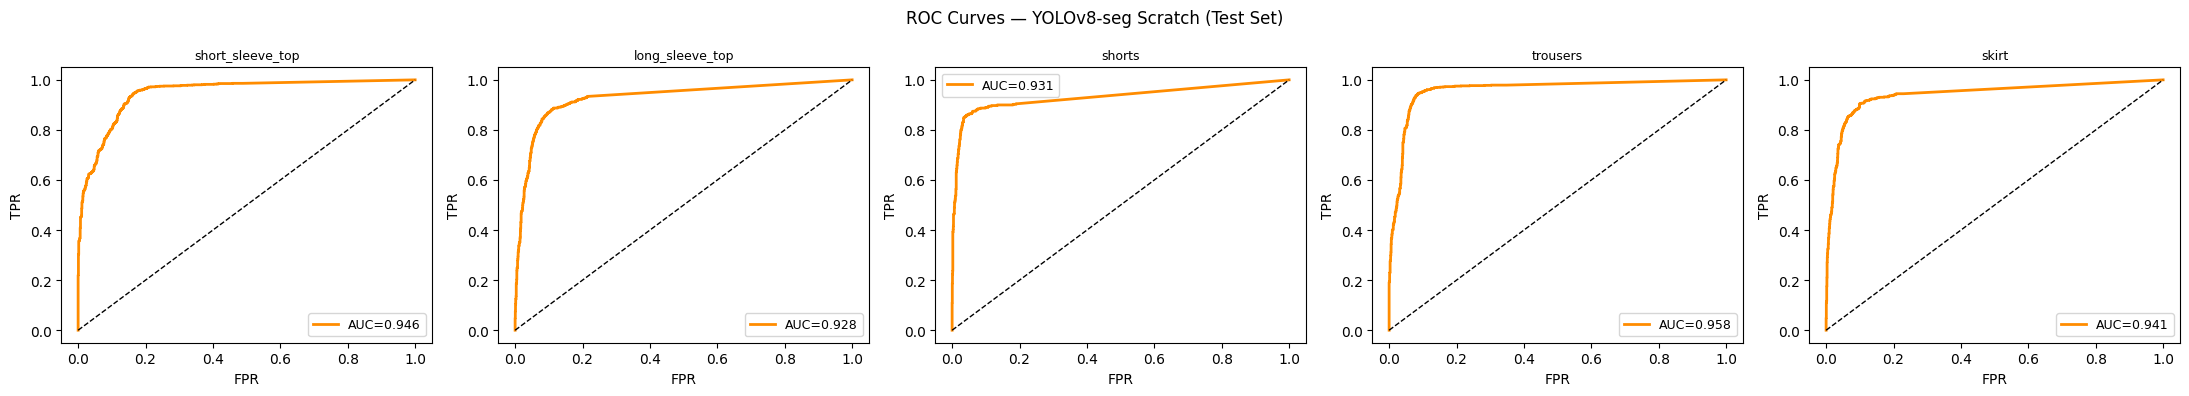

In [16]:
def compute_roc_auc_detection(model, test_img_dir, test_lbl_dir, imgsz=640):
    """
    For each image, get max confidence per class from predictions,
    and GT binary presence per class.
    Returns per-class arrays for ROC computation.
    """
    all_scores = defaultdict(list)   # class -> list of predicted confidence
    all_labels = defaultdict(list)   # class -> list of GT presence (0/1)

    test_images = sorted(glob.glob(os.path.join(test_img_dir, '*.jpg')))
    print(f'Computing ROC/AUC on {len(test_images)} test images...')

    for img_path in tqdm(test_images):
        stem = Path(img_path).stem
        lbl_path = os.path.join(test_lbl_dir, stem + '.txt')
        if not os.path.exists(lbl_path):
            continue

        # GT classes present in this image
        gt_classes = set()
        with open(lbl_path) as f:
            for line in f:
                gt_classes.add(int(line.strip().split()[0]))

        # Predicted confidence per class (max over all instances)
        result = model(img_path, imgsz=imgsz, conf=0.001, verbose=False)[0]  # low conf to get scores
        pred_conf_per_class = defaultdict(float)
        if result.boxes is not None and len(result.boxes):
            for conf, cls in zip(result.boxes.conf.cpu().numpy(),
                                 result.boxes.cls.cpu().numpy().astype(int)):
                pred_conf_per_class[cls] = max(pred_conf_per_class[cls], float(conf))

        for cls_id in range(NUM_CLASSES):
            all_scores[cls_id].append(pred_conf_per_class[cls_id])
            all_labels[cls_id].append(1 if cls_id in gt_classes else 0)

    return all_scores, all_labels


roc_scores, roc_labels = compute_roc_auc_detection(
    best_model,
    f'{YOLO_DIR}/images/test',
    f'{YOLO_DIR}/labels/test',
)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
print(f'\n{"Class":<22} {"AUC":>8}')
print('-'*32)
aucs = []
for i, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    y_true = np.array(roc_labels[i])
    y_score = np.array(roc_scores[i])
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        print(f'{name:<22} {"N/A":>8}  (only one class in GT)')
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        continue
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    aucs.append(auc)
    ax.plot(fpr, tpr, lw=2, color='darkorange', label=f'AUC={auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=9)
    print(f'{name:<22} {auc:>8.4f}')
if aucs:
    print(f'{"Macro-avg":<22} {np.mean(aucs):>8.4f}')

plt.suptitle('ROC Curves — YOLOv8-seg Scratch (Test Set)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/roc_scratch_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Training Curves

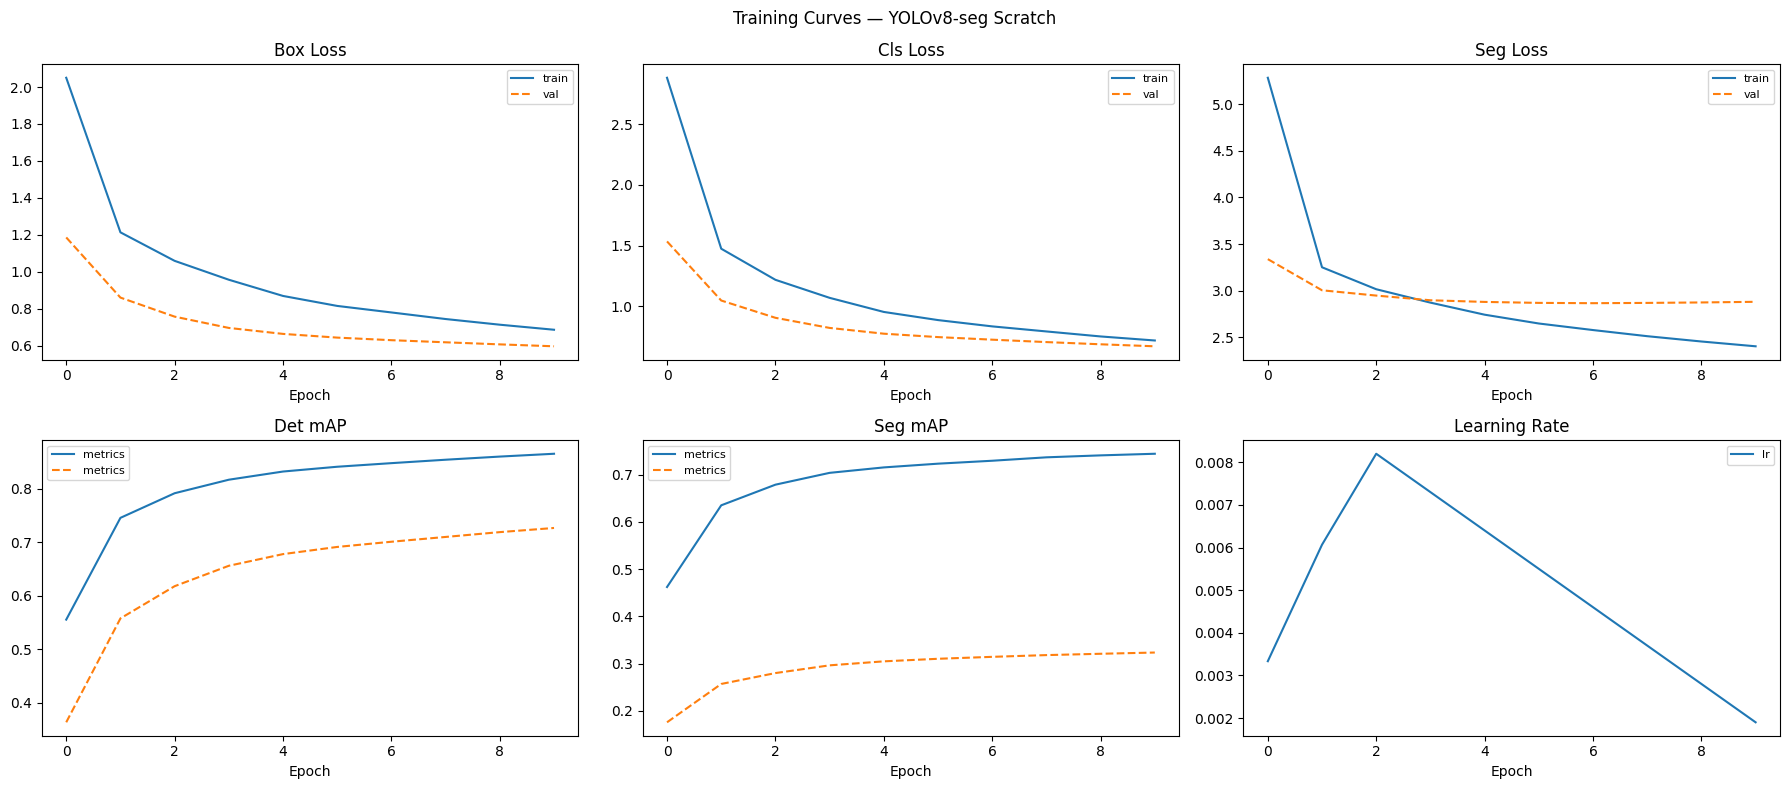

In [20]:
# Ultralytics saves results.csv with all metrics per epoch
import pandas as pd

results_csv = f'/kaggle/input/datasets/arnavoruganty/results/results.csv'
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    plot_pairs = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Cls Loss'),
        ('train/seg_loss', 'val/seg_loss', 'Seg Loss'),
        ('metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'Det mAP'),
        ('metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'Seg mAP'),
        ('lr/pg0', None, 'Learning Rate'),
    ]
    for ax, (col1, col2, title) in zip(axes.flat, plot_pairs):
        if col1 in df.columns:
            ax.plot(df[col1], label=col1.split('/')[0])
        if col2 and col2 in df.columns:
            ax.plot(df[col2], label=col2.split('/')[0], linestyle='--')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
    plt.suptitle('Training Curves — YOLOv8-seg Scratch', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/curves_scratch.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'results.csv not found at {results_csv}')

## 13. Qualitative Visualisation

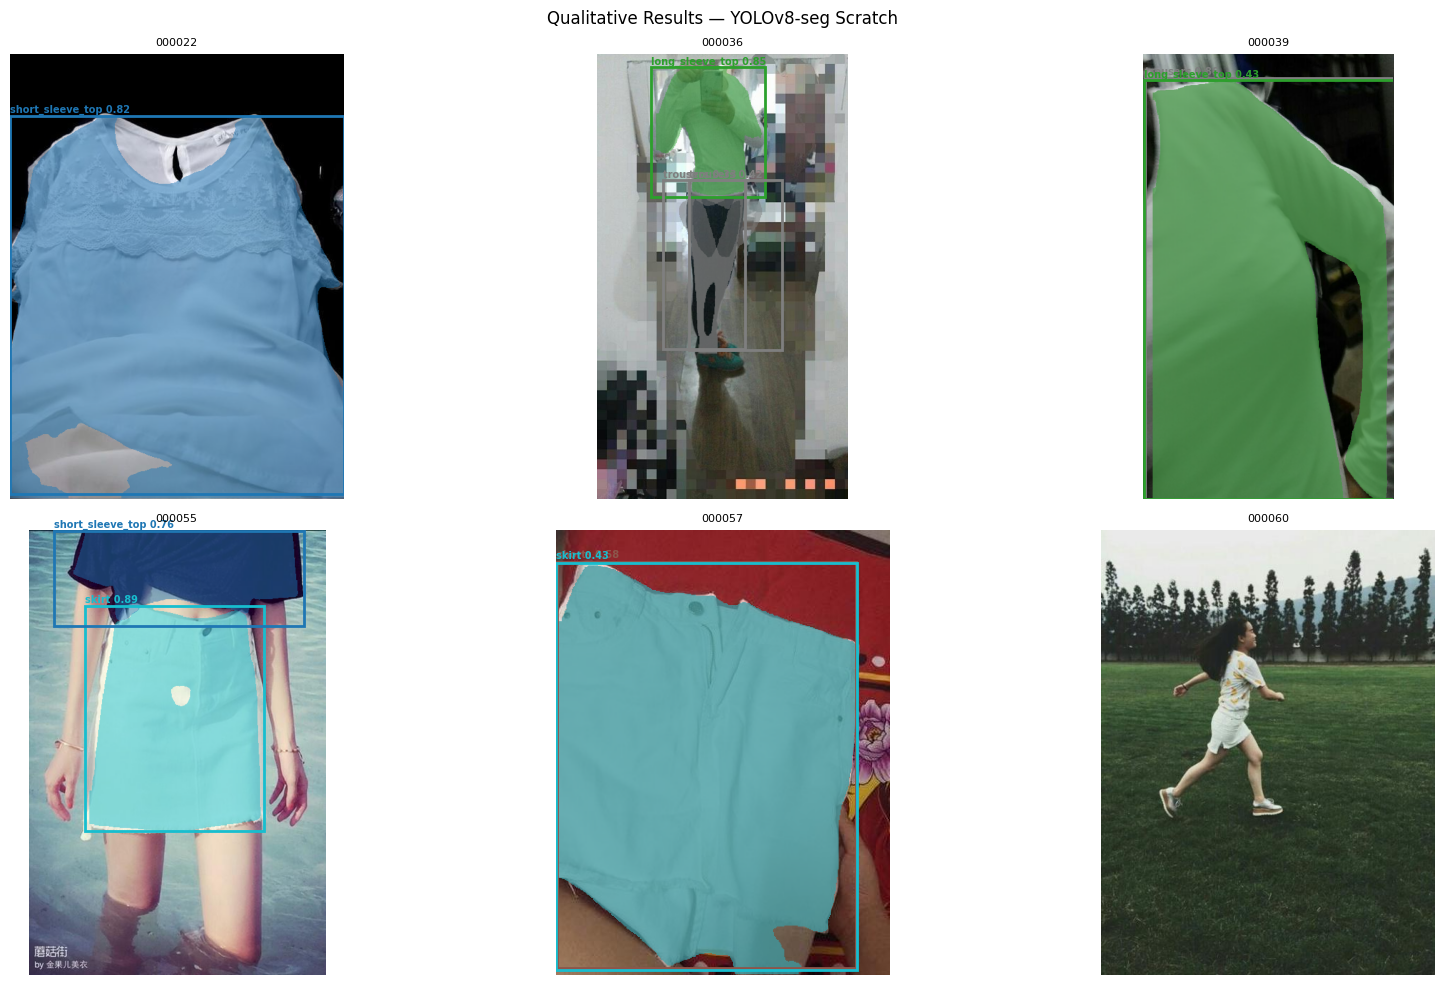

In [21]:
COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

test_images = sorted(glob.glob(f'{YOLO_DIR}/images/test/*.jpg'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, img_path in zip(axes.flat, test_images):
    result = best_model(img_path, imgsz=IMGSZ, conf=0.25, verbose=False)[0]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy().astype(np.float32)

    if result.masks is not None:
        h, w = img_rgb.shape[:2]
        for mask, cls_id in zip(result.masks.data.cpu().numpy(),
                                result.boxes.cls.cpu().numpy().astype(int)):
            m = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
            color = (np.array(COLORS[cls_id % NUM_CLASSES][:3]) * 255)
            overlay[m == 1] = overlay[m == 1] * 0.5 + color * 0.5

    ax.imshow(overlay.astype(np.uint8))

    if result.boxes is not None and len(result.boxes):
        for box, cls_id, conf in zip(result.boxes.xyxy.cpu().numpy(),
                                      result.boxes.cls.cpu().numpy().astype(int),
                                      result.boxes.conf.cpu().numpy()):
            x1,y1,x2,y2 = box.astype(int)
            color = COLORS[cls_id % NUM_CLASSES][:3]
            rect = mpatches.Rectangle((x1,y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-4, f'{CLASS_NAMES[cls_id]} {conf:.2f}',
                    color=color, fontsize=7, fontweight='bold')
    ax.axis('off')
    ax.set_title(Path(img_path).stem, fontsize=8)

plt.suptitle('Qualitative Results — YOLOv8-seg Scratch', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/qualitative_scratch.png', dpi=150, bbox_inches='tight')
plt.show()